In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/GUVI Capstone projects/Project5/train.csv")


In [2]:
print(df.head())


   id      Name  Gender   Age           City Working Professional or Student  \
0   0  Aaradhya  Female  49.0       Ludhiana            Working Professional   
1   1     Vivan    Male  26.0       Varanasi            Working Professional   
2   2    Yuvraj    Male  33.0  Visakhapatnam                         Student   
3   3    Yuvraj    Male  22.0         Mumbai            Working Professional   
4   4      Rhea  Female  30.0         Kanpur            Working Professional   

         Profession  Academic Pressure  Work Pressure  CGPA  \
0              Chef                NaN            5.0   NaN   
1           Teacher                NaN            4.0   NaN   
2               NaN                5.0            NaN  8.97   
3           Teacher                NaN            5.0   NaN   
4  Business Analyst                NaN            1.0   NaN   

   Study Satisfaction  Job Satisfaction     Sleep Duration Dietary Habits  \
0                 NaN               2.0  More than 8 hours     

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [5]:
print("\nDepression value counts:\n", df['Depression'].value_counts(normalize=True))


Depression value counts:
 Depression
0    0.818287
1    0.181713
Name: proportion, dtype: float64


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
print("\nMissing Values:\n")
print(missing_df[missing_df['Missing Values'] > 0])


Missing Values:

                    Missing Values  Percentage
Study Satisfaction          112803   80.172708
Academic Pressure           112803   80.172708
CGPA                        112802   80.171997
Profession                   36630   26.034115
Work Pressure                27918   19.842217
Job Satisfaction             27910   19.836532
Financial Stress                 4    0.002843
Dietary Habits                   4    0.002843
Degree                           2    0.001421


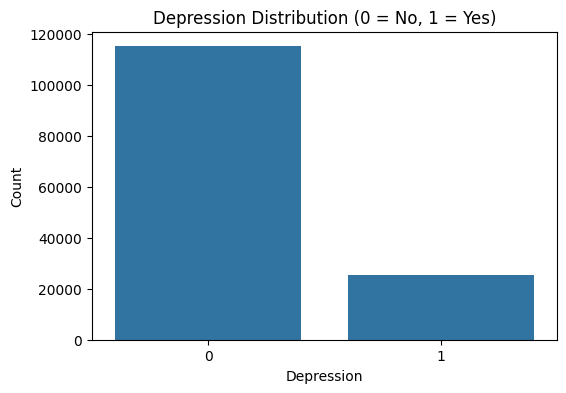

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Depression', data=df)
plt.title('Depression Distribution (0 = No, 1 = Yes)')
plt.xlabel('Depression')
plt.ylabel('Count')
plt.show()

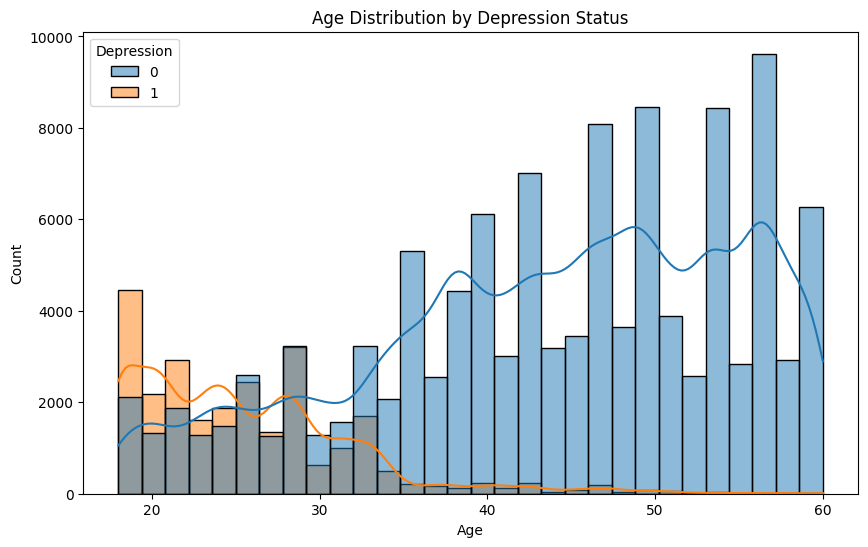

In [9]:
# Age Distribution by Depression
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Depression', bins=30, kde=True)
plt.title("Age Distribution by Depression Status")
plt.show()

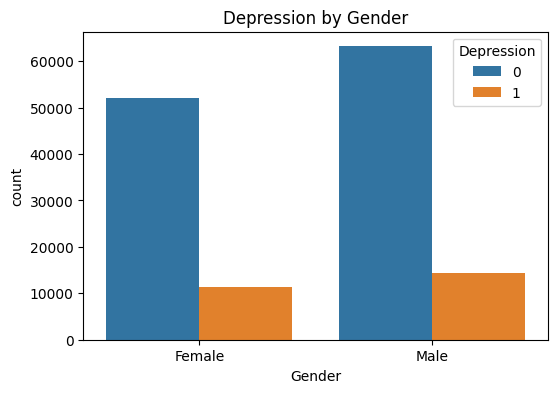

In [10]:
# Gender vs Depression
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Depression', data=df)
plt.title('Depression by Gender')
plt.show()

In [26]:
# Sleep Duration
new_df=df.groupby(['Sleep Duration']).agg({
    'Depression':'count'}
).sort_values(by='Depression', ascending=False).head()



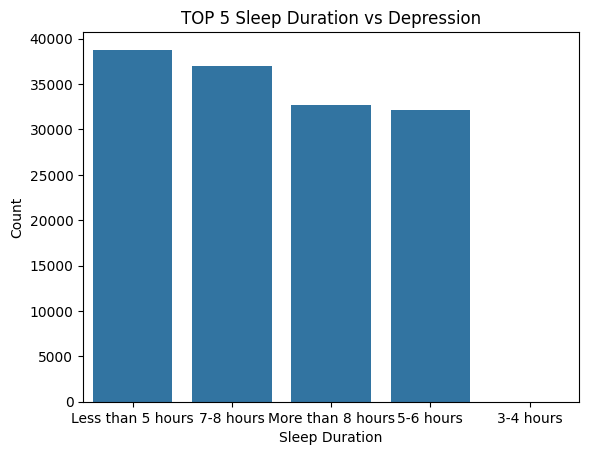

In [27]:
sns.barplot(x=new_df.index, y=new_df['Depression'])
plt.title('TOP 5 Sleep Duration vs Depression')
plt.xlabel('Sleep Duration')
plt.ylabel('Count')
plt.show()

In [38]:
new_df=df.groupby(['Dietary Habits']).agg({
    'Depression':'count'}
).sort_values(by='Depression', ascending=False)
new_df

,Depression
Dietary Habits,
Moderate,49705
Unhealthy,46227
Healthy,44741
No,2
More Healthy,2
Yes,2
1.0,1
Gender,1
Electrician,1


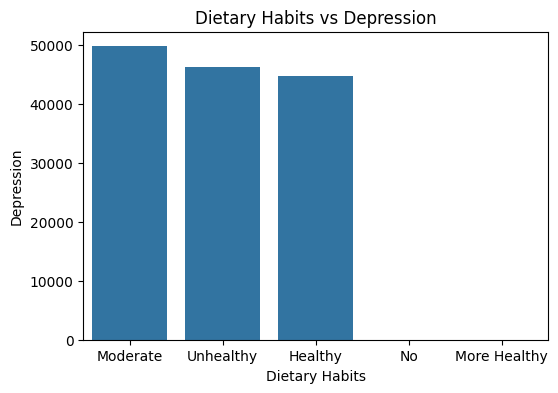

In [34]:
# Dietary Habits
plt.figure(figsize=(6,4))
sns.barplot(data=new_df, x='Dietary Habits', y='Depression')
plt.title("Dietary Habits vs Depression")
plt.show()

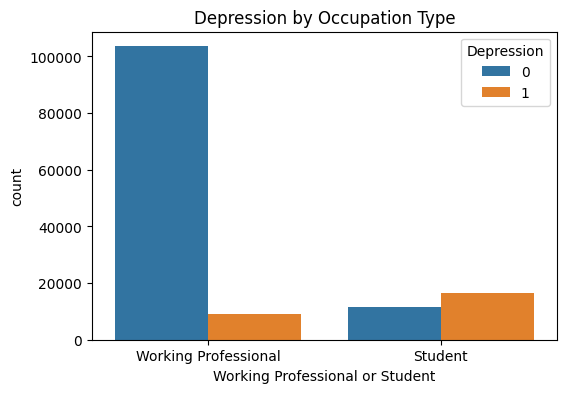

In [39]:
# Student vs Professional
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Working Professional or Student', hue='Depression')
plt.title("Depression by Occupation Type")
plt.show()

 Academic & Job Pressure/Satisfaction

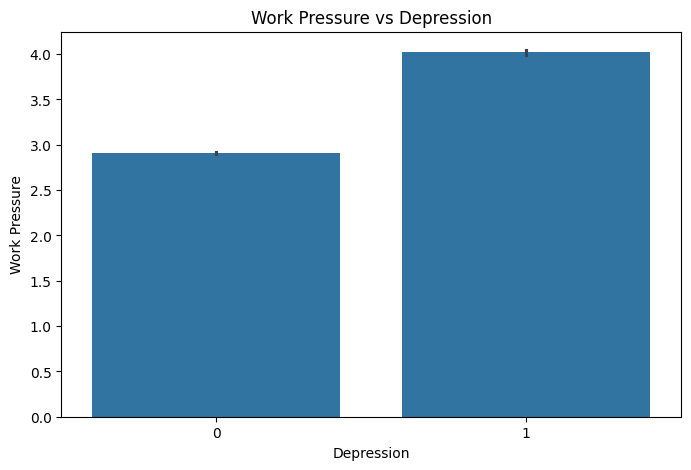

In [5]:
# Work Pressure vs Depression
plt.figure(figsize=(8,5))
sns.barplot(x='Depression', y='Work Pressure', data=df)
plt.title('Work Pressure vs Depression')
plt.show()

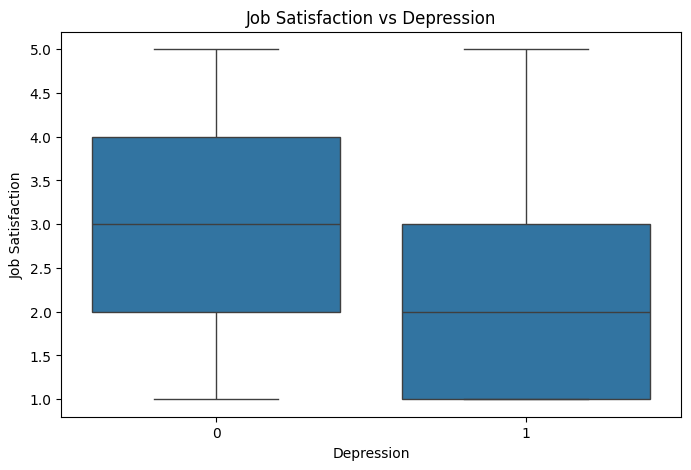

In [6]:
# Job Satisfaction
plt.figure(figsize=(8,5))
sns.boxplot(x='Depression', y='Job Satisfaction', data=df)
plt.title('Job Satisfaction vs Depression')
plt.show()

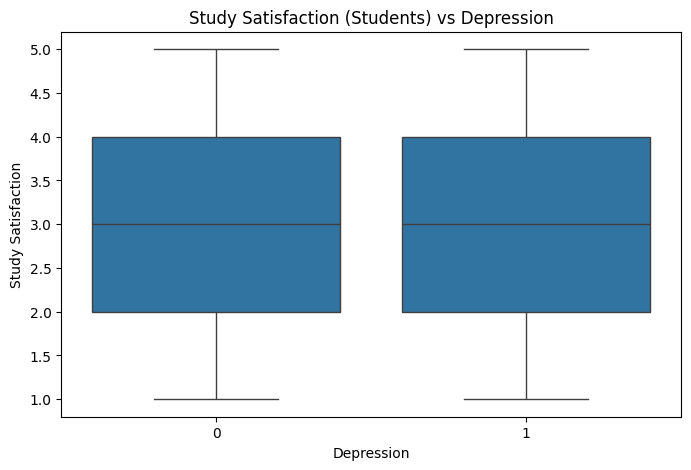

In [7]:
# Study Satisfaction (students only)
students = df[df['Working Professional or Student'] == 'Student']
plt.figure(figsize=(8,5))
sns.boxplot(x='Depression', y='Study Satisfaction', data=students)
plt.title('Study Satisfaction (Students) vs Depression')
plt.show()

Suicidal Thoughts, Family History, Financial Stress

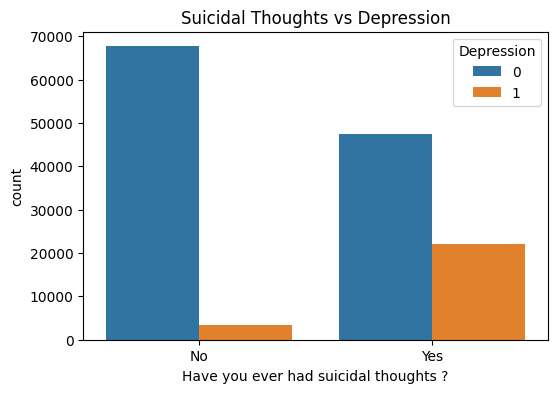

In [8]:
# Suicidal Thoughts
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Have you ever had suicidal thoughts ?', hue='Depression')
plt.title("Suicidal Thoughts vs Depression")
plt.show()

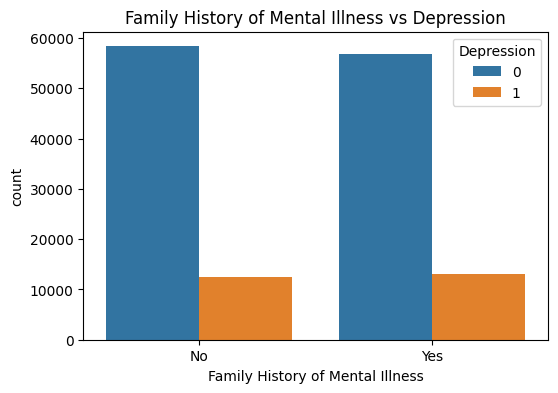

In [9]:
# Family History
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Family History of Mental Illness', hue='Depression')
plt.title("Family History of Mental Illness vs Depression")
plt.show()

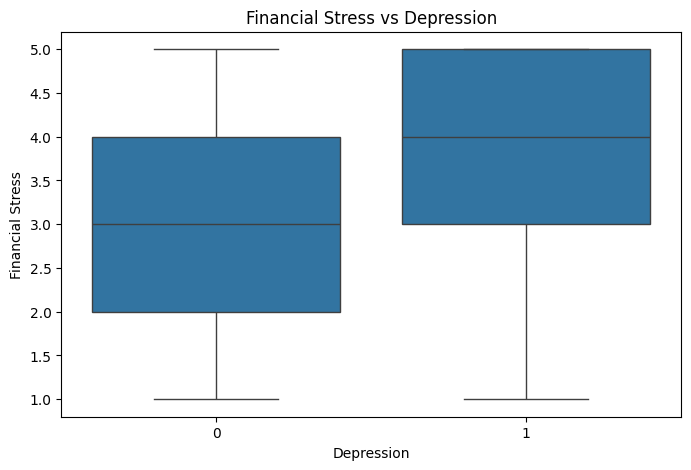

In [10]:
# Financial Stress
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Depression', y='Financial Stress')
plt.title("Financial Stress vs Depression")
plt.show()

Work/Study Hours vs Depression

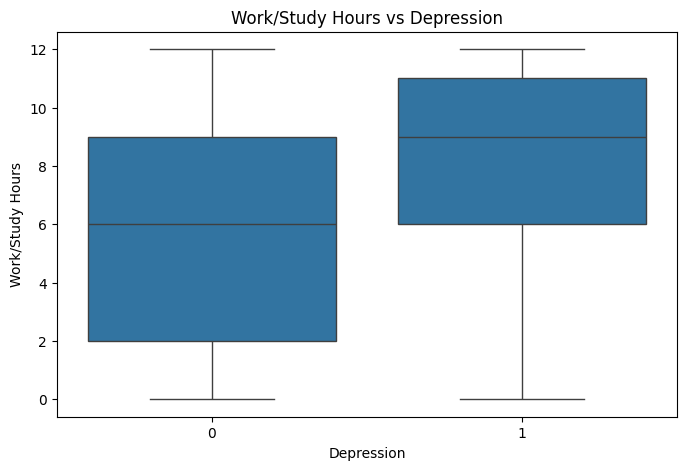

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Depression', y='Work/Study Hours')
plt.title("Work/Study Hours vs Depression")
plt.show()

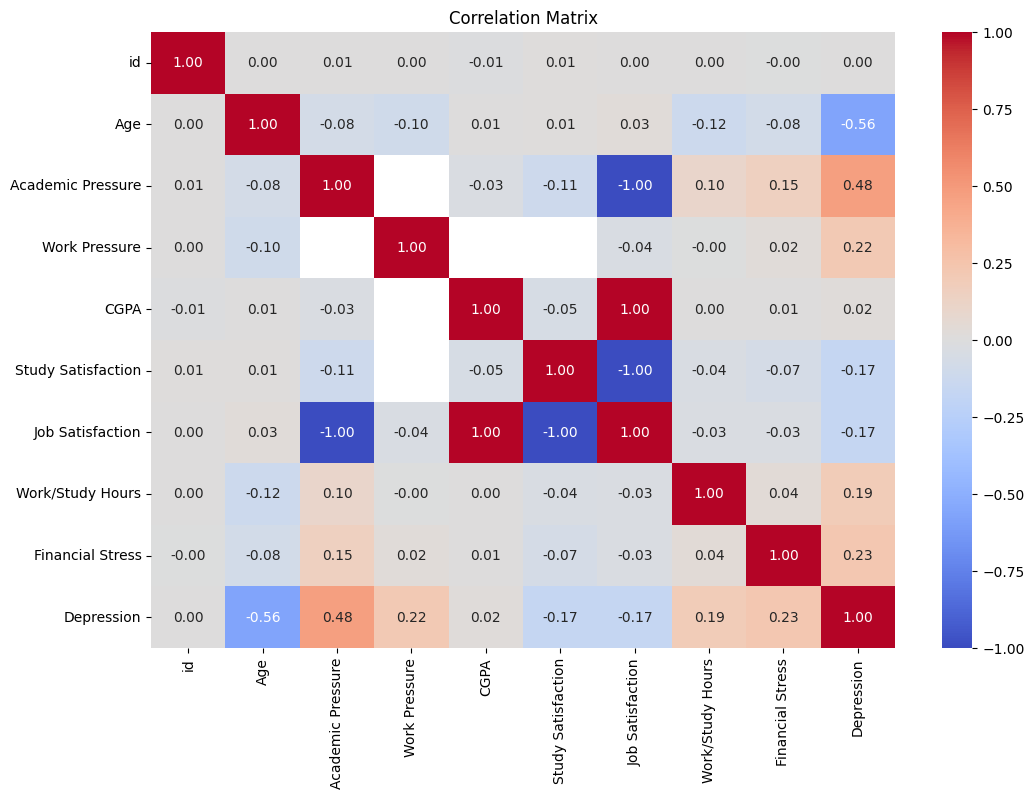

In [12]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

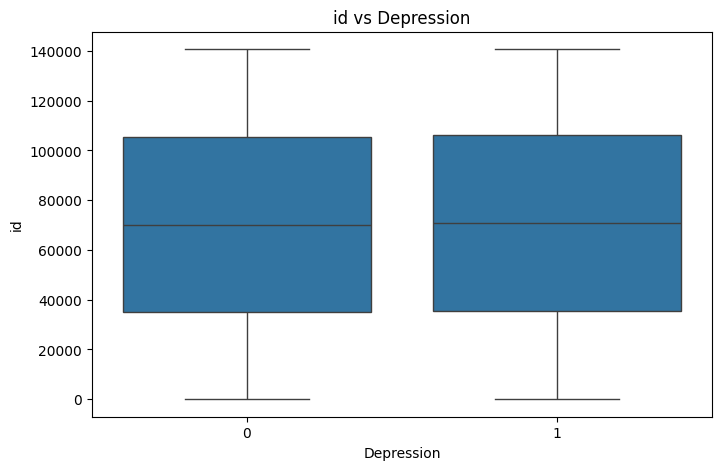

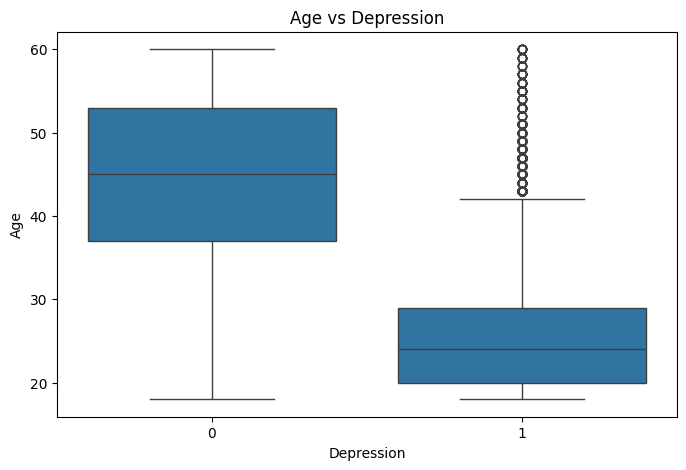

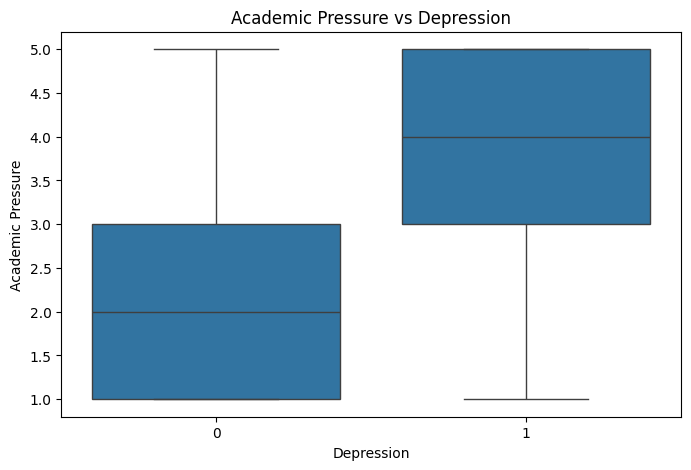

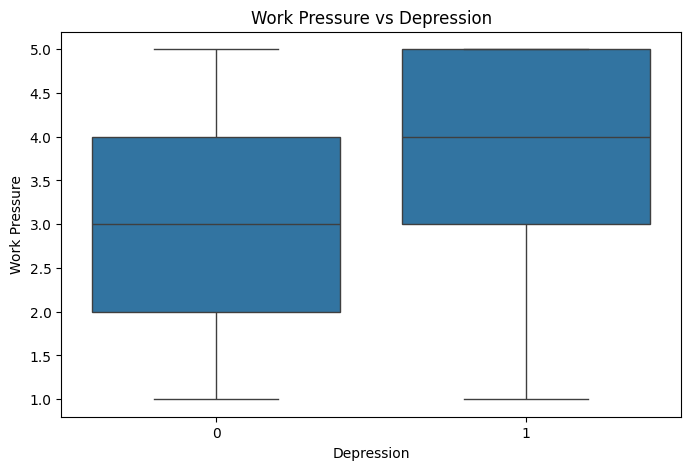

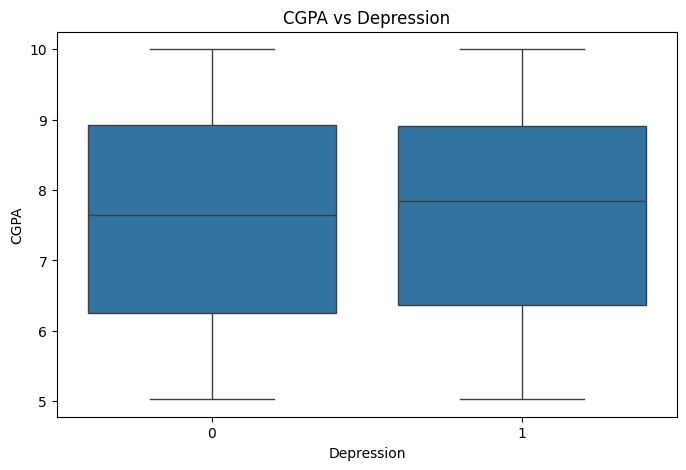

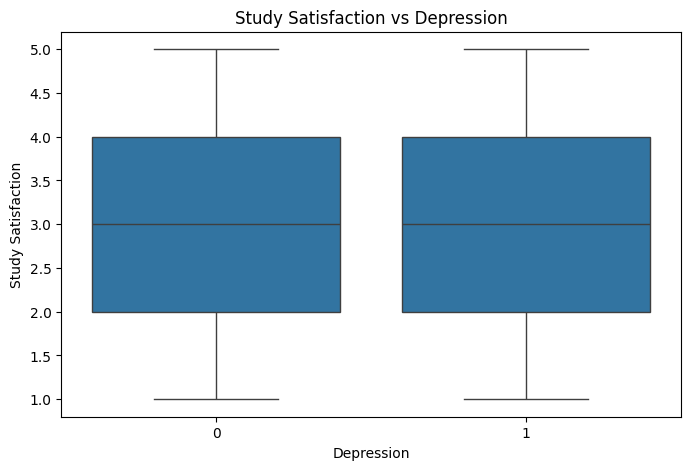

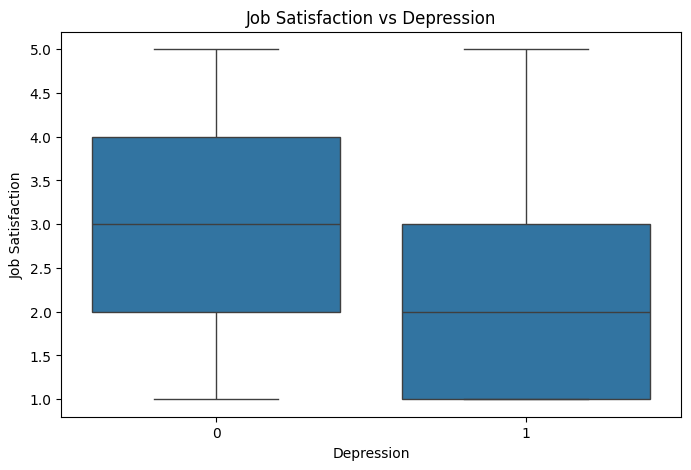

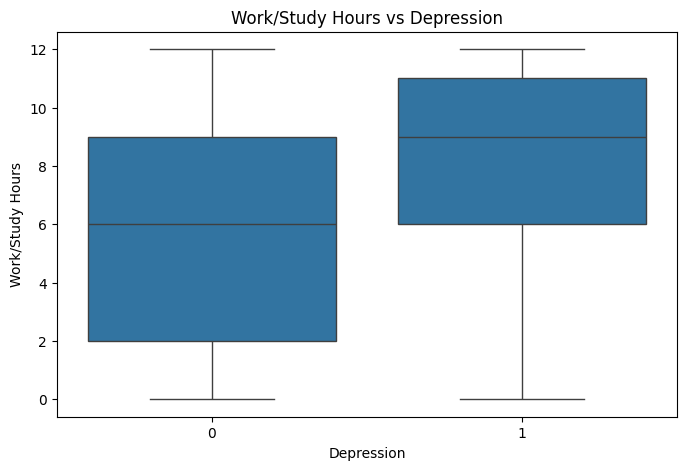

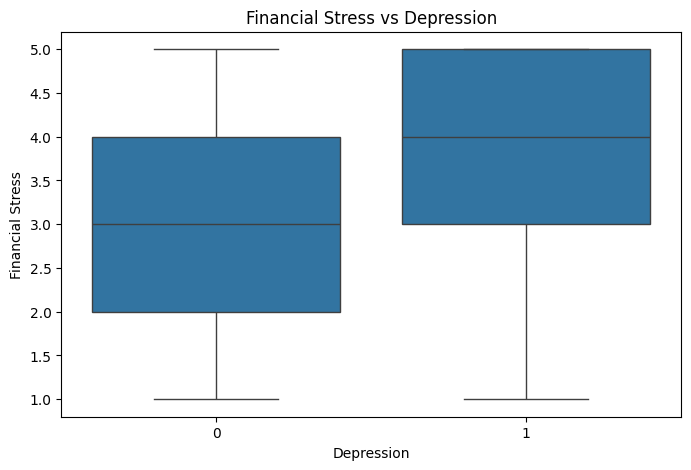

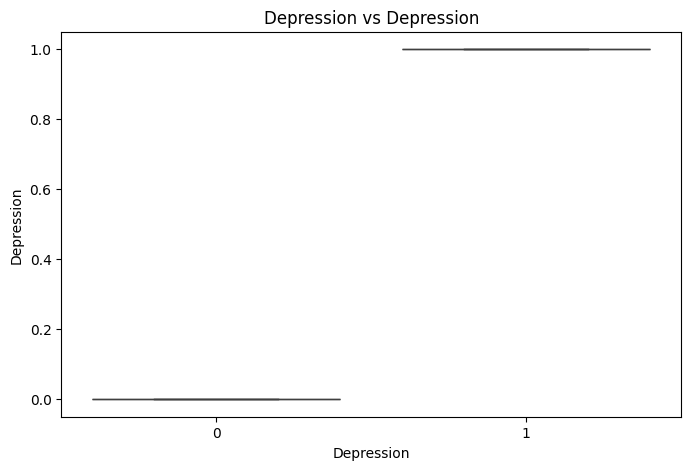

In [13]:
for i in df.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Depression', y=i)
    plt.title(f"{i} vs Depression")
    plt.show()